Libraries imported successfully!
Pandas Version: 2.2.3
NumPy Version:  2.1.3

--- 2. NUMPY OPERATIONS ---
1D Array: [10 20 30 40 50]

2D Array:
 [[56 45 89 18]
 [20 90 68 76]
 [92 21 48 60]
 [66 58 49 61]]

Element-wise Addition (+10): [20 30 40 50 60]
Square Root: [3.16227766 4.47213595 5.47722558 6.32455532 7.07106781]

Mean of 2D Array:     57.31
Max Value in 2D Array:  92
Standard Deviation:     22.91

Reshaped 1D to (5,1):
 [[10]
 [20]
 [30]
 [40]
 [50]]
Slicing 2D Array (First 2 rows, first 2 cols):
 [[56 45]
 [20 90]]

--- 3. PANDAS OPERATIONS ---

1. Data Overview (Head):
   Employee_ID Department   Age   Salary  Performance_Score
0          101         IT  25.0  65000.0                3.8
1          102         HR  32.0  52000.0                4.2
2          103         IT  29.0  71000.0                4.0

2. Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  


/tmp/ipykernel_790/1797398809.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


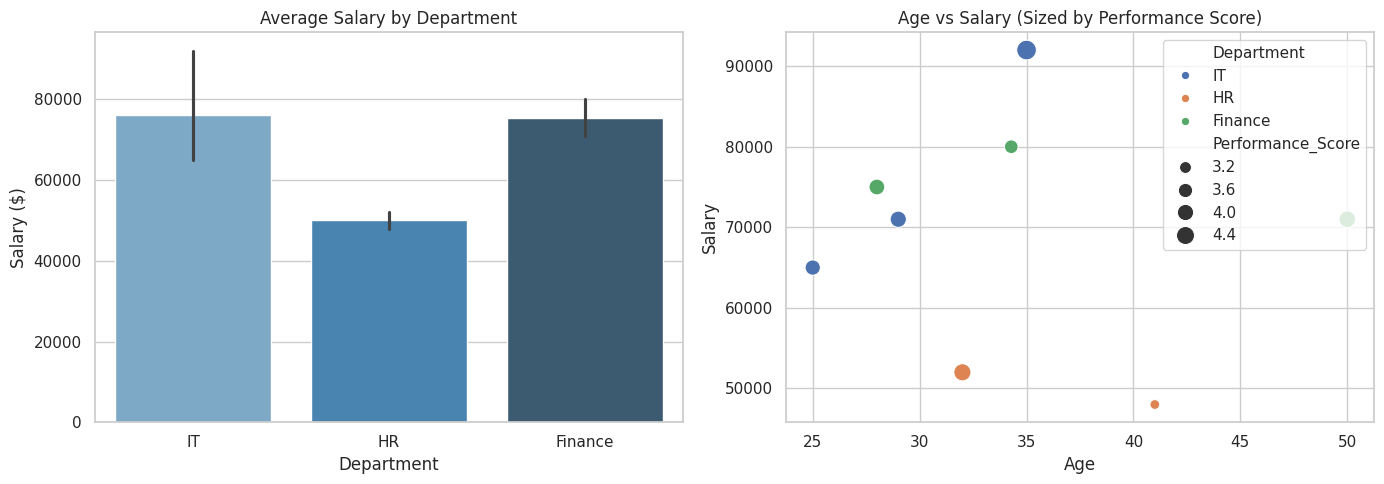

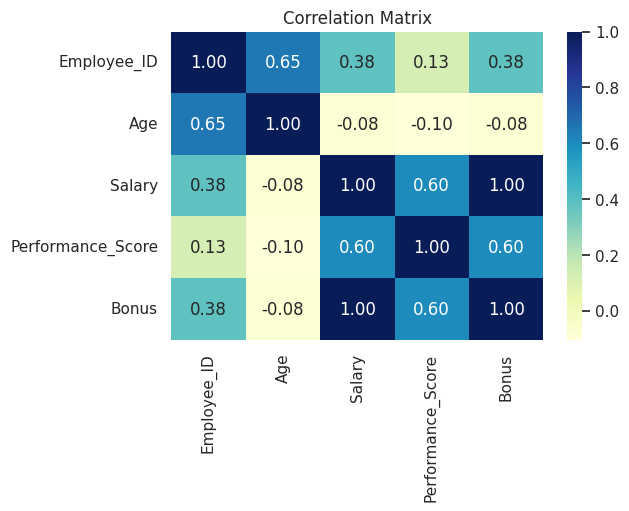

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully!")
print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version:  {np.__version__}\n")


print("--- 2. NUMPY OPERATIONS ---")

arr_1d = np.array([10, 20, 30, 40, 50])
arr_2d = np.random.randint(10, 100, size=(4, 4))

print("1D Array:", arr_1d)
print("\n2D Array:\n", arr_2d)

print("\nElement-wise Addition (+10):", arr_1d + 10)
print("Square Root:", np.sqrt(arr_1d))

print(f"\nMean of 2D Array:     {np.mean(arr_2d):.2f}")
print(f"Max Value in 2D Array:  {np.max(arr_2d)}")
print(f"Standard Deviation:     {np.std(arr_2d):.2f}")

reshaped = arr_1d.reshape(5, 1)
print("\nReshaped 1D to (5,1):\n", reshaped)
print("Slicing 2D Array (First 2 rows, first 2 cols):\n", arr_2d[:2, :2])


print("\n--- 3. PANDAS OPERATIONS ---")

data = {
    'Employee_ID': [101, 102, 103, 104, 105, 106, 107, 108],
    'Department': ['IT', 'HR', 'IT', 'Finance', 'HR', 'IT', 'Finance', 'Finance'],
    'Age': [25, 32, 29, np.nan, 41, 35, 28, 50],  # Introduced missing value (NaN)
    'Salary': [65000, 52000, 71000, 80000, 48000, 92000, 75000, np.nan],
    'Performance_Score': [3.8, 4.2, 4.0, 3.5, 2.9, 4.8, 3.9, 4.1]
}

df = pd.DataFrame(data)

print("\n1. Data Overview (Head):")
print(df.head(3))

print("\n2. Dataset Information:")
df.info()

print("\n3. Statistical Summary:")
print(df.describe())

print("\n4. Missing Values Count:")
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

df['Bonus'] = df['Salary'] * 0.10

high_earners = df[df['Salary'] > 70000]
print("\n5. Employees with Salary > 70,000:")
print(high_earners[['Employee_ID', 'Department', 'Salary']])

print("\n6. Average Salary and Age by Department:")
dept_summary = df.groupby('Department')[['Salary', 'Age', 'Performance_Score']].mean()
print(dept_summary)



print("\n--- 4. VISUALIZATIONS ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=df,
    x='Department',
    y='Salary',
    estimator=np.mean,
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title("Average Salary by Department")
axes[0].set_ylabel("Salary ($)")

sns.scatterplot(
    data=df,
    x='Age',
    y='Salary',
    hue='Department',
    size='Performance_Score',
    sizes=(50, 200),
    ax=axes[1]
)
axes[1].set_title("Age vs Salary (Sized by Performance Score)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()